In [56]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

%matplotlib widget

# Resolve project root (parent of notebooks/)
ROOT = Path.cwd().absolute().parent

RUN_ID = "20260312_105807__e01766af7b7e__rpm3333p3__feed40p000__fs10000"

# Extract identifiers
timestamp_id = RUN_ID.split("__")[0]
hash_id = RUN_ID.split("__")[1]

# Construct paths
PARAMS_PATH    = ROOT / "data" / "experiments" / "settings" / hash_id / "params.json"
EXPERIMENT_CSV = ROOT / "data" / "experiments" / RUN_ID / "experiment_data.csv"
TRACE_CSV      = ROOT / "data" / "experiments" / RUN_ID / "path_trace.csv"

# Load params
with open(PARAMS_PATH, encoding="utf-8") as f:
    params = json.load(f)

# Load experiment data
df = pd.read_csv(EXPERIMENT_CSV)


print(f"Run-ID: {RUN_ID}")
print(f"Timestamp ID: {timestamp_id}")
print(f"Params hash: {hash_id}\n")

print("Experiment columns:")
print(*df.columns.tolist(), sep="\n")

print("\nParams:")
print(json.dumps(params, indent=4))

Run-ID: 20260312_105807__e01766af7b7e__rpm3333p3__feed40p000__fs10000
Timestamp ID: 20260312_105807
Params hash: e01766af7b7e

Experiment columns:
time_s
x_x_m
x_y_m
u_x_N
u_y_N
fmill_x_N
fmill_y_N
tool_center_nominal_x_mm
tool_center_nominal_y_mm
tool_center_actual_x_mm
tool_center_actual_y_mm
tool_orientation

Params:
{
    "axial_cutting_depth_mm": 5.0,
    "dt": 0.0001,
    "feed_per_tooth_mm": 0.09000000000000001,
    "feed_profile_csv": "optimized_feed/optimization_offline_cc/Optimal_feed_curve.csv",
    "feed_speed_mm_s": 40.0,
    "feed_speed_path_mm_s": 40.0,
    "frequency_hz": 55.55555555555555,
    "linearized_model_npz": null,
    "micro_mass_diag_kg": null,
    "milling_path_csv": "data/paths/Workpiece_long_with_start_milling_path.csv",
    "min_feed_speed_mm_s": 1.0,
    "omega_rad_s": -349.06585039886585,
    "path_offset_mm": null,
    "path_offset_side": "left",
    "period": 0.018000000000000002,
    "rev_per_s": 55.55555555555555,
    "rpm": 3333.333333333333,
    "

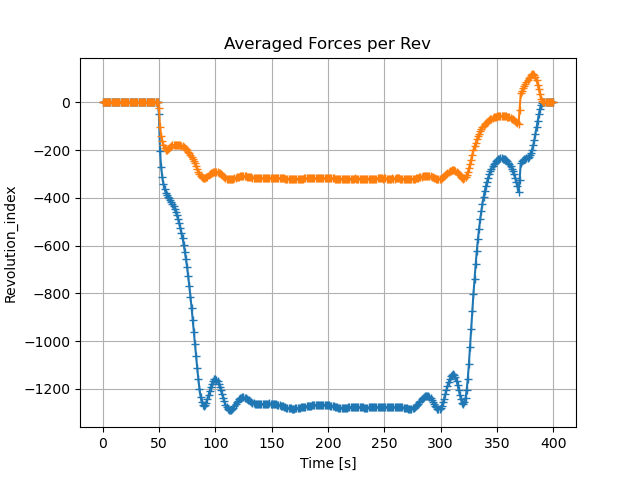

0.0001


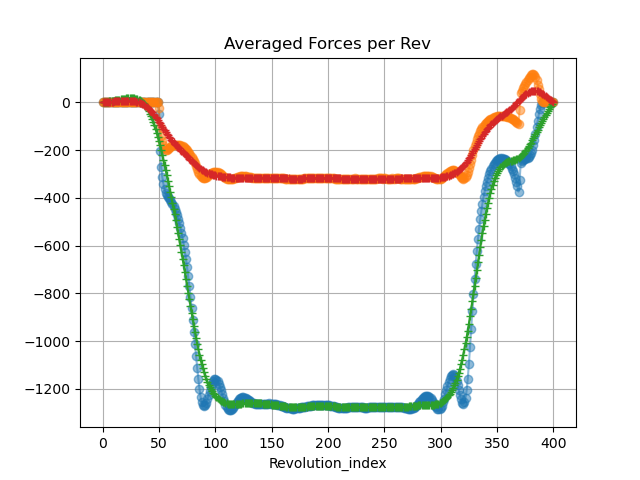

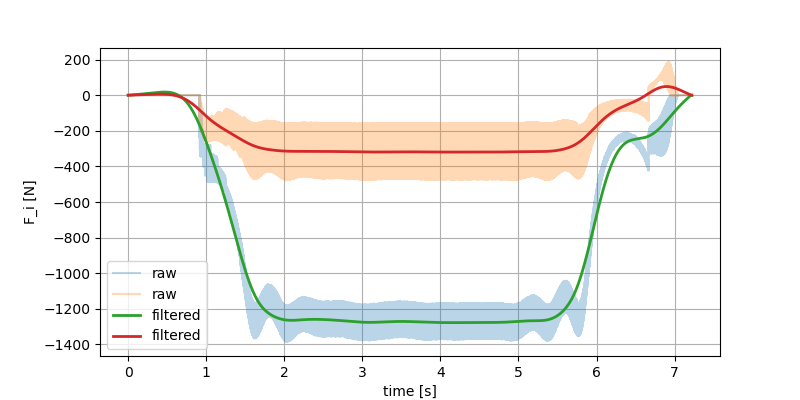

In [52]:
def binned_average(df: pd.DataFrame, bin_size: int, cols, time_col="time_s") -> pd.DataFrame:
    n_bins = len(df) // bin_size
    df = df.iloc[:n_bins * bin_size]

    force_avg = (
        df[cols]
        .to_numpy()
        .reshape(n_bins, bin_size, len(cols))
        .mean(axis=1)
    )

    time_avg = (
        df[[time_col]]
        .to_numpy()
        .reshape(n_bins, bin_size, 1)
        .mean(axis=1)
        .ravel()
    )

    return pd.DataFrame({
        "time": time_avg,
        "rev_idx": np.arange(n_bins),
        "n_samples": bin_size,
        "fmill_avg_x_N": force_avg[:, 0],
        "fmill_avg_y_N": force_avg[:, 1],
    })

samples_per_rev = params["samples_per_period"]
binned_rev_average_df = binned_average(df, samples_per_rev , ["fmill_x_N", "fmill_y_N"])

plt.figure()
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fmill_avg_x_N"] , marker = "+")
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fmill_avg_y_N"] , marker = "+")
plt.xlabel("Time [s]")
plt.ylabel("Revolution_index")
plt.title("Averaged Forces per Rev")
plt.grid(True)
plt.show()

print(params["dt"])

f_n = 1.0
order  = 2
b, a = signal.butter(order, f_n  , fs = 1/(params["dt"] * samples_per_rev))
binned_rev_average_df["fx_filt"]  = signal.filtfilt(b, a, binned_rev_average_df["fmill_avg_x_N"].to_numpy() , padlen=200)
binned_rev_average_df["fy_filt"]  = signal.filtfilt(b, a, binned_rev_average_df["fmill_avg_y_N"].to_numpy() , padlen=200)



# Interpolate filtered forces
df["fmill_x_filt_N"] = np.interp(
    df["time_s"].to_numpy(),
    binned_rev_average_df["time"].to_numpy(),
    binned_rev_average_df["fx_filt"]
)

df["fmill_y_filt_N"] = np.interp(
    df["time_s"].to_numpy(),
    binned_rev_average_df["time"].to_numpy(),
    binned_rev_average_df["fy_filt"]
)

plt.figure()
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fmill_avg_x_N"] , alpha = 0.5,  marker = "o")
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fmill_avg_y_N"], alpha = 0.5 , marker = "o")
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fx_filt"]  ,marker = "+")
plt.plot(binned_rev_average_df["rev_idx"] , binned_rev_average_df["fy_filt"]  ,marker = "+")

plt.xlabel("Revolution_index")
plt.ylabel("")
plt.title("Averaged Forces per Rev")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,4))

plt.plot(df["time_s"], df["fmill_x_N"], alpha=0.3, label="raw")
plt.plot(df["time_s"], df["fmill_y_N"], alpha=0.3, label="raw")
plt.plot(df["time_s"], df["fmill_x_filt_N"], linewidth=2, label="filtered")
plt.plot(df["time_s"], df["fmill_y_filt_N"], linewidth=2, label="filtered")

plt.xlabel("time [s]")
plt.ylabel("F_i [N]")
plt.legend()
plt.grid(True)


,time_s,tool_center_x_mm,tool_center_y_mm,Fx_feedforward_time_N,Fy_feedforward_time_N
0,0.0000,5.000000,-190.0000,3.395380e-07,8.005674e-08
1,0.0001,4.999999,-189.9999,3.395380e-07,8.005674e-08
2,0.0002,4.999997,-189.9998,3.395380e-07,8.005674e-08
3,0.0003,4.999996,-189.9997,3.395380e-07,8.005674e-08
4,0.0004,4.999994,-189.9996,3.395380e-07,8.005674e-08


,time_s,tool_center_x_mm,tool_center_y_mm,Fx_feedforward_time_N,Fy_feedforward_time_N
72207,7.2207,5.083002,9.968103,-6.790526e-07,-1.598726e-07
72208,7.2208,5.083215,9.974376,-6.790526e-07,-1.598726e-07
72209,7.2209,5.083428,9.980650,-6.790526e-07,-1.598726e-07
72210,7.2210,5.083642,9.986927,-6.790526e-07,-1.598726e-07
72211,7.2211,5.083855,9.993204,-6.790526e-07,-1.598726e-07


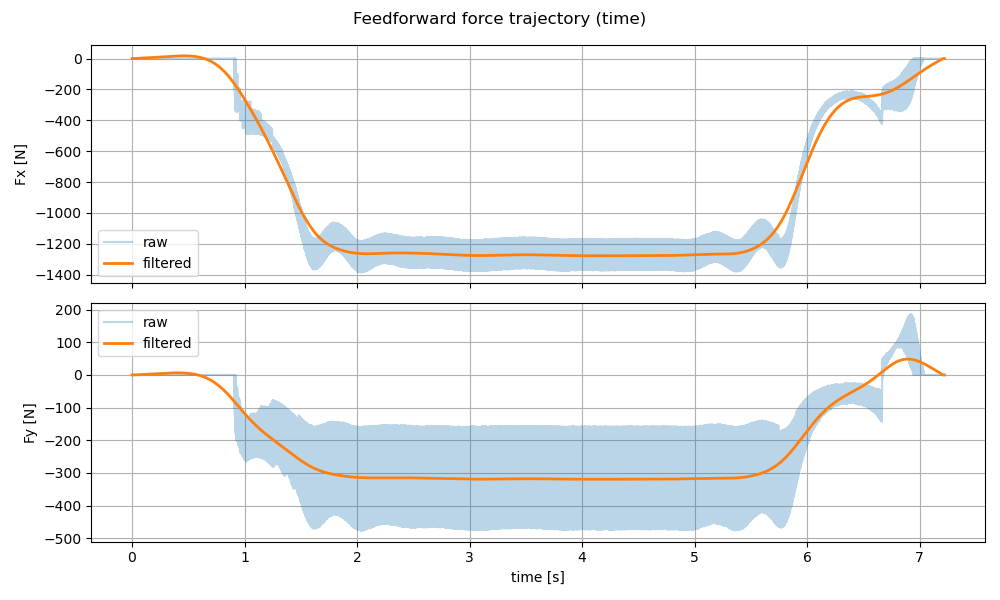

In [66]:

t_original = df["time_s"].to_numpy()
t_rev = binned_rev_average_df["time"].to_numpy()


# Time interpolation
fx_time_interp = np.interp(
    t_original,
    t_rev,
    binned_rev_average_df["fx_filt"]
)

fy_time_interp = np.interp(
    t_original,
    t_rev,
    binned_rev_average_df["fy_filt"]
)

feedforward_df = pd.DataFrame({
    "time_s": df["time_s"],

    "tool_center_x_mm": df["tool_center_actual_x_mm"],
    "tool_center_y_mm": df["tool_center_actual_y_mm"],

    "Fx_feedforward_time_N": fx_time_interp,
    "Fy_feedforward_time_N": fy_time_interp,
})

display(feedforward_df.head())
display(feedforward_df.tail())

fig, ax = plt.subplots(2,1, figsize=(10,6), sharex=True)

ax[0].plot(df["time_s"], df["fmill_x_N"], alpha=0.3, label="raw")
ax[0].plot(feedforward_df["time_s"], feedforward_df["Fx_feedforward_time_N"], linewidth=2, label="filtered")
ax[0].set_ylabel("Fx [N]")
ax[0].legend()
ax[0].grid()

ax[1].plot(df["time_s"], df["fmill_y_N"], alpha=0.3, label="raw")
ax[1].plot(feedforward_df["time_s"], feedforward_df["Fy_feedforward_time_N"], linewidth=2, label="filtered")
ax[1].set_ylabel("Fy [N]")
ax[1].set_xlabel("time [s]")
ax[1].legend()
ax[1].grid()

fig.suptitle("Feedforward force trajectory (time)")
plt.tight_layout()

In [65]:
FEEDFORWARD_DIR = ROOT / "data" / "feedforward"
FEEDFORWARD_DIR.mkdir(exist_ok=True)

outfile = FEEDFORWARD_DIR / f"{timestamp_id}__feedforward_force.csv"

feedforward_df.to_csv(outfile, index=False)

print("Saved feedforward trajectory:")
print(outfile)

Saved feedforward trajectory:
/home/irz/code/milling_sim_study/data/feedforward/20260312_105807__feedforward_force.csv
